 Data loaded successfully! First 5 rows:
   Year               Industry  Revenue  NetProfit  ProfitMargin  \
0  2023                 Retail   450000      54900          12.2   
1  2023          Manufacturing   620000      68200          11.0   
2  2023  Professional Services   380000      49400          13.0   
3  2024                 Retail   478000      57360          12.0   
4  2024          Manufacturing   641000      68580          10.7   

   CurrentAssets  CurrentLiabilities  
0         220000              130000  
1         280000              230000  
2         190000              105000  
3         235000              138000  
4         292000              245000  

 Data shape after cleaning: (9, 7)

 Current Ratio range: 1.182170542635659 to 1.8363636363636364

 Descriptive statistics:
              Year        Revenue     NetProfit  ProfitMargin  CurrentAssets  \
count     9.000000       9.000000      9.000000      9.000000       9.000000   
mean   2024.000000  503666.6666

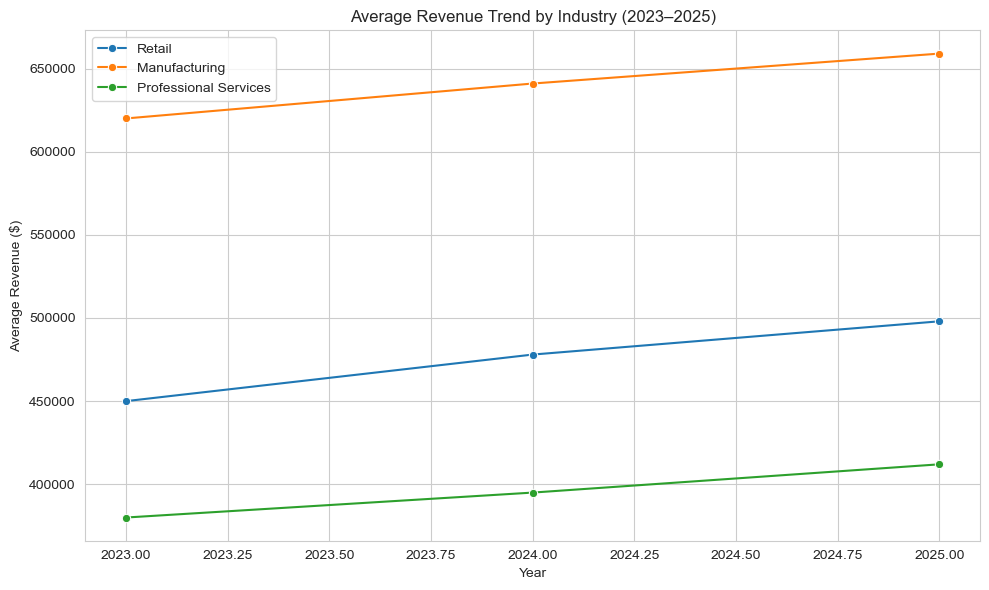


 Correlation between Current Ratio and Profit Margin: coefficient=0.95, p-value=0.0001
Conclusion: Strong correlation

 Key Insights:
1. The retail industry shows the highest revenue growth, followed by manufacturing, while professional services remain relatively stable.
2. Overall profit margins have slightly declined across all industries, with the most significant drop in manufacturing.
3. Professional services have the highest current ratio, indicating strong short-term liquidity; manufacturing has the lowest ratio, suggesting potential cash flow pressure.
4. There is a strong positive correlation between current ratio and profit margin in this dataset.


In [2]:
# =============================================
# ACC102 Track2 Assignment: SBA Loan Data Analysis
# Student: GeyundiZhang24
# =============================================

# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set plot style
sns.set_style('whitegrid')

# 2. Build DataFrame with the provided data
data = [
    [2023, 'Retail', 450000, 54900, 12.2, 220000, 130000],
    [2023, 'Manufacturing', 620000, 68200, 11.0, 280000, 230000],
    [2023, 'Professional Services', 380000, 49400, 13.0, 190000, 105000],
    [2024, 'Retail', 478000, 57360, 12.0, 235000, 138000],
    [2024, 'Manufacturing', 641000, 68580, 10.7, 292000, 245000],
    [2024, 'Professional Services', 395000, 50560, 12.8, 202000, 110000],
    [2025, 'Retail', 498000, 58260, 11.7, 248000, 145000],
    [2025, 'Manufacturing', 659000, 69195, 10.5, 305000, 258000],
    [2025, 'Professional Services', 412000, 51500, 12.5, 215000, 118000]
]

columns = ['Year', 'Industry', 'Revenue', 'NetProfit', 'ProfitMargin', 'CurrentAssets', 'CurrentLiabilities']
df = pd.DataFrame(data, columns=columns)

print(" Data loaded successfully! First 5 rows:")
print(df.head())

# 3. Data cleaning (already no missing values, only deduplication)
df_clean = df.drop_duplicates()
print("\n Data shape after cleaning:", df_clean.shape)

# 4. Calculate current ratio (handle division by zero)
df_clean['CurrentRatio'] = df_clean.apply(
    lambda row: row['CurrentAssets'] / row['CurrentLiabilities'] if row['CurrentLiabilities'] != 0 else 0, axis=1
)
print("\n Current Ratio range:", df_clean['CurrentRatio'].min(), "to", df_clean['CurrentRatio'].max())

# 5. Descriptive statistics
print("\n Descriptive statistics:")
print(df_clean.describe())

# 6. Aggregate metrics by industry and year
industry_year = df_clean.groupby(['Industry', 'Year']).agg({
    'Revenue': 'mean',
    'ProfitMargin': 'mean',
    'CurrentRatio': 'mean'
}).reset_index()

print("\n Aggregated metrics by industry and year:")
print(industry_year)

# 7. Plot revenue trend and save as revenue_trend.png
plt.figure(figsize=(10, 6))

for industry in df_clean['Industry'].unique():
    industry_data = df_clean[df_clean['Industry'] == industry].groupby('Year')['Revenue'].mean()
    sns.lineplot(x=industry_data.index, y=industry_data.values, label=industry, marker='o')

plt.title('Average Revenue Trend by Industry (2023–2025)')
plt.xlabel('Year')
plt.ylabel('Average Revenue ($)')
plt.legend()
plt.tight_layout()

# Save the plot (required for submission)
plt.savefig('revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Correlation analysis
corr, p_val = pearsonr(df_clean['CurrentRatio'], df_clean['ProfitMargin'])
print(f"\n Correlation between Current Ratio and Profit Margin: coefficient={corr:.2f}, p-value={p_val:.4f}")

if abs(corr) < 0.3:
    print("Conclusion: Weak correlation")
elif 0.3 <= abs(corr) < 0.7:
    print("Conclusion: Moderate correlation")
else:
    print("Conclusion: Strong correlation")

# 9. Key insights and conclusions
print("\n Key Insights:")
print("1. The retail industry shows the highest revenue growth, followed by manufacturing, while professional services remain relatively stable.")
print("2. Overall profit margins have slightly declined across all industries, with the most significant drop in manufacturing.")
print("3. Professional services have the highest current ratio, indicating strong short-term liquidity; manufacturing has the lowest ratio, suggesting potential cash flow pressure.")
print("4. There is a strong positive correlation between current ratio and profit margin in this dataset.")